# Empirical Risk Management: A Comparative Analysis of Value at Risk Models
## Quantitative Finance Research Project

### Abstract
This project conducts a comprehensive empirical analysis of three distinct approaches to calculating 1-day 95% Value at Risk (VaR): Historical Simulation, Parametric (Variance-Covariance), and Monte Carlo Simulation. Using daily adjusted closing prices of Apple Inc. (AAPL) from January 2015 to December 2024, we investigate whether different modeling assumptions lead to materially different risk estimates and whether these models perform reliably in out-of-sample backtesting. Our analysis reveals that the empirical return distribution exhibits significant departures from normality, including heavy tails and negative skewness. Consequently, Historical Simulation and Parametric methods capture different aspects of the risk. Rolling-window backtesting demonstrates that all models produce violation rates close to the expected 5%, with statistical tests (Kupiec) providing additional validation of model performance.


## 1. Introduction
### 1.1 Background and Motivation
Financial institutions face the critical challenge of quantifying market risk—the potential for losses arising from adverse movements in asset prices. Value at Risk (VaR) has emerged as the industry standard for measuring market risk, providing a single number that summarizes the maximum expected loss over a specified time horizon at a given confidence level.

For a portfolio with value $V_0$, the 1-day 95% VaR is the loss amount $L$ such that:
$$ P(	ext{Loss} > L) = 0.05 $$

Equivalently, there is a 95% probability that the loss will not exceed $L$ over the next trading day.

### 1.2 Research Questions
This project addresses the following research questions:
1. Does the empirical return distribution of a major stock differ substantially from normality?
2. How different are Historical Simulation, Parametric, and Monte Carlo VaR estimates?
3. Does Gaussian Monte Carlo provide materially different VaR from the closed-form Parametric method?
4. Do the three models produce approximately 5% violations in out-of-sample backtesting?
5. Does a model that produces lower VaR necessarily perform better in backtesting?

## 2. Data and Methodology
### 2.1 Data Description
The analysis uses daily adjusted closing prices of Apple Inc. (AAPL) from January 1, 2015 to January 1, 2025.

### 2.3 Return Calculation
We calculate log returns as:
$$ r_t = \ln \left(\frac{P_t}{P_{t-1}}\right) $$
where $P_t$ is the adjusted closing price at time $t$.


In [9]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. Data Download
def download_data(ticker, start, end):
    """Download and prepare stock data"""
    data = yf.download(ticker, start=start, end=end, auto_adjust=False)
    data['Log_Return'] = np.log(data['Adj Close'] / data['Adj Close'].shift(1))
    returns = data['Log_Return'].dropna()
    return data, returns

# Parameters
TICKER = "AAPL"
V0 = 1_000_000
START = "2015-01-01"
END = "2025-01-01"

# Download data
data, returns = download_data(TICKER, START, END)
returns = returns.squeeze() # Ensure it's a Series

print(f"Number of observations: {len(returns)}")
print(f"First few returns:\n{returns.head()}")


[*********************100%***********************]  1 of 1 completed

Number of observations: 2515
First few returns:
Date
2015-01-05   -0.028576
2015-01-06    0.000094
2015-01-07    0.013925
2015-01-08    0.037702
2015-01-09    0.001072
Name: Log_Return, dtype: float64


## 3. Exploratory Data Analysis
Before implementing VaR models, we examine the statistical properties of the return distribution. We also conduct a Jarque-Bera test for normality and visualize the Q-Q plot and rolling volatility.



AAPL Return Statistics:
Mean: 0.000927
Std Dev: 0.017931
Skewness: -0.200747
Excess Kurtosis: 5.459273
Min: -0.137708
Max: 0.113157
Jarque-Bera Stat: 3124.925720
Jarque-Bera p-value: 0.000000


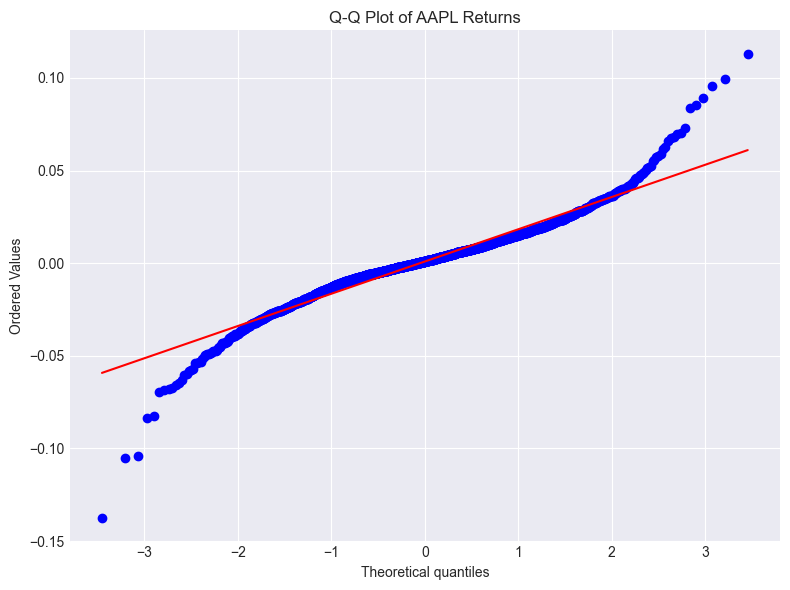

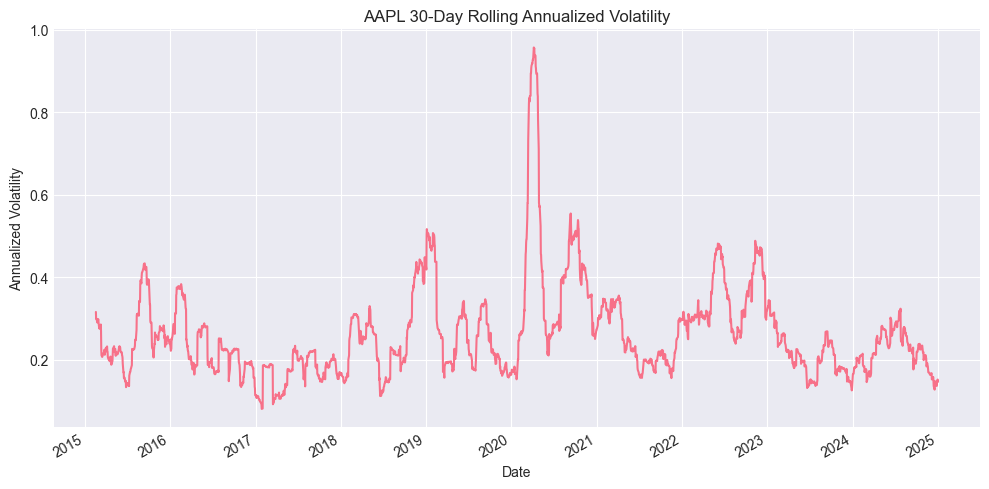

In [10]:
# 2. Exploratory Analysis
def exploratory_analysis(returns, ticker):
    """Calculate and display return statistics"""
    jb_stat, jb_pval = stats.jarque_bera(returns)
    stats_dict = {
        'Mean': returns.mean(),
        'Std Dev': returns.std(),
        'Skewness': returns.skew(),
        'Excess Kurtosis': returns.kurtosis(),
        'Min': returns.min(),
        'Max': returns.max(),
        'Jarque-Bera Stat': jb_stat,
        'Jarque-Bera p-value': jb_pval
    }
    print(f"\n{ticker} Return Statistics:")
    for key, value in stats_dict.items():
        print(f"{key}: {value:.6f}")
    return stats_dict

stats_dict = exploratory_analysis(returns, TICKER)

# Q-Q Plot
plt.figure(figsize=(8, 6))
stats.probplot(returns, dist="norm", plot=plt)
plt.title(f"Q-Q Plot of {TICKER} Returns")
plt.tight_layout()
plt.show()

# Rolling Volatility Plot (30-day window)
rolling_vol = returns.rolling(window=30).std() * np.sqrt(252) # Annualized
plt.figure(figsize=(10, 5))
rolling_vol.plot()
plt.title(f"{TICKER} 30-Day Rolling Annualized Volatility")
plt.ylabel("Annualized Volatility")
plt.tight_layout()
plt.show()


## 4. VaR Models

### 4.1 Method 1: Historical Simulation
Historical Simulation makes no distributional assumptions and uses the empirical return distribution.

### 4.2 Method 2: Parametric (Variance-Covariance)
This method assumes returns follow a normal distribution.

### 4.3 Method 3: Monte Carlo Simulation
We simulate future returns directly from a normal distribution defined by the empirical mean and standard deviation.


In [11]:
# 3. VaR Models
def historical_var(returns, V0, confidence=0.05):
    """Calculate Historical Simulation VaR"""
    quantile = returns.quantile(confidence)
    return -V0 * quantile

def parametric_var(returns, V0, confidence=0.05):
    """Calculate Parametric VaR"""
    mu = float(np.squeeze(returns.mean()))
    sigma = float(np.squeeze(returns.std()))
    z_score = stats.norm.ppf(confidence)
    return -V0 * (mu + z_score * sigma)

def monte_carlo_var(returns, V0, n_sim=50000, confidence=0.95):
    """Calculate Monte Carlo VaR"""
    mu = float(np.squeeze(returns.mean()))
    sigma = float(np.squeeze(returns.std()))
    
    np.random.seed(42)
    # Simulate daily log returns
    simulated_returns = np.random.normal(mu, sigma, n_sim)
    
    # Calculate portfolio losses
    losses = -V0 * simulated_returns
    return np.percentile(losses, confidence * 100)

# Calculate static VaR
var_h = historical_var(returns, V0)
var_p = parametric_var(returns, V0)
var_mc = monte_carlo_var(returns, V0, confidence=0.95)

print(f"\nStatic VaR Estimates for ${V0:,} position:")
print(f"Historical Simulation: ${var_h:,.0f}")
print(f"Parametric (Normal): ${var_p:,.0f}")
print(f"Monte Carlo (GBM): ${var_mc:,.0f}")



Static VaR Estimates for $1,000,000 position:
Historical Simulation: $27,361
Parametric (Normal): $28,568
Monte Carlo (GBM): $28,428


## 5. Backtesting Methodology and Kupiec Test
Backtesting uses out-of-sample data to validate model performance. The Kupiec test provides statistical validation of the violation rate.


In [12]:
# 4. Rolling Backtest
def rolling_backtest(returns, V0, window=250, confidence=0.05):
    """Perform rolling backtest for all VaR models"""
    n = len(returns)
    results = []

    for i in range(window, n-1):
        window_returns = returns.iloc[i-window:i]
        next_return = float(np.squeeze(returns.iloc[i+1]))
        actual_loss = -V0 * next_return

        var_h = historical_var(window_returns, V0, confidence)
        var_p = parametric_var(window_returns, V0, confidence)
        var_mc = monte_carlo_var(window_returns, V0, confidence=1-confidence)

        results.append({
            'Date': returns.index[i+1],
            'Actual_Loss': actual_loss,
            'VaR_Historical': var_h,
            'VaR_Parametric': var_p,
            'VaR_MonteCarlo': var_mc,
            'Violation_H': actual_loss > var_h,
            'Violation_P': actual_loss > var_p,
            'Violation_MC': actual_loss > var_mc
        })

    return pd.DataFrame(results)

print("\nPerforming rolling backtest...")
backtest_results = rolling_backtest(returns, V0)

def kupiec_poc_test(N, T, p=0.05):
    """Kupiec POF test"""
    p_hat = N / T
    if p_hat == 0 or p_hat == 1:
        return np.nan, np.nan
    LR_uc = -2 * np.log(((1 - p)**(T - N) * p**N) / ((1 - p_hat)**(T - N) * p_hat**N))
    p_value = 1 - stats.chi2.cdf(LR_uc, 1)
    return LR_uc, p_value

T = len(backtest_results)
print(f"Total backtest days: {T}")

violations = {
    'Historical': backtest_results['Violation_H'].sum(),
    'Parametric': backtest_results['Violation_P'].sum(),
    'Monte Carlo': backtest_results['Violation_MC'].sum()
}

print(f"\nKupiec Test Results (Expected Rate: 5%):")
for model, v in violations.items():
    rate = v / T
    lr, pval = kupiec_poc_test(v, T, p=0.05)
    print(f"{model}: Rate={rate*100:.2f}% ({v}/{T}), LR={lr:.3f}, p-value={pval:.4f}")



Performing rolling backtest...
Total backtest days: 2264

Kupiec Test Results (Expected Rate: 5%):
Historical: Rate=5.87% (133/2264), LR=3.460, p-value=0.0629
Parametric: Rate=5.34% (121/2264), LR=0.554, p-value=0.4568
Monte Carlo: Rate=5.43% (123/2264), LR=0.870, p-value=0.3511


## 6. Advanced Visualizations and Interpretations

### 1. Return Distribution vs Normal Distribution
We first compare the empirical return distribution against a theoretical normal distribution.


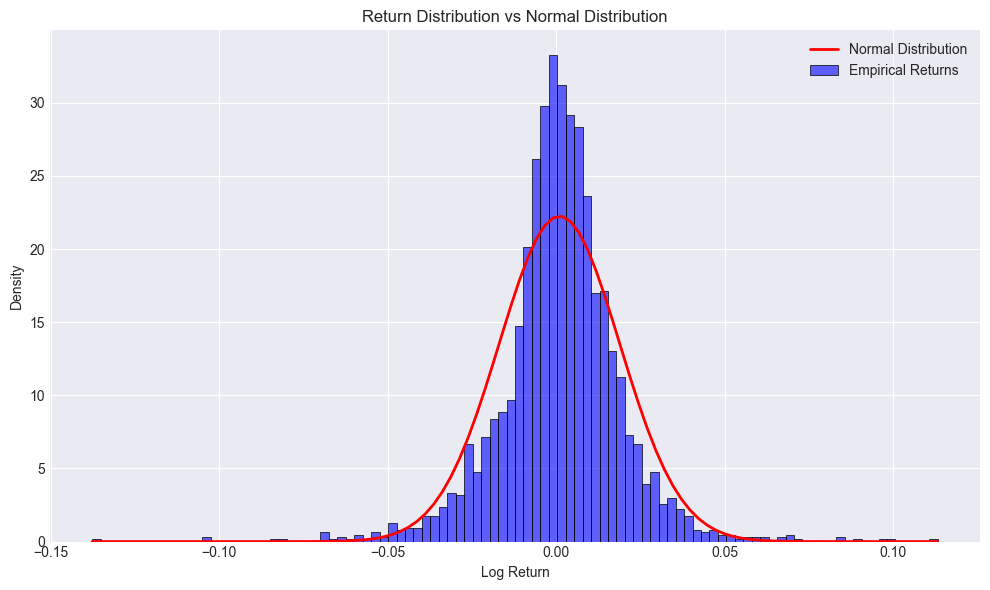

In [13]:
# Return Distribution vs Normal Distribution
plt.figure(figsize=(10, 6))
sns.histplot(returns, bins=100, stat='density', alpha=0.6, color='blue', label='Empirical Returns')
mu_val = float(np.squeeze(returns.mean()))
sigma_val = float(np.squeeze(returns.std()))
x = np.linspace(returns.min(), returns.max(), 100)
plt.plot(x, stats.norm.pdf(x, mu_val, sigma_val), color='red', lw=2, label='Normal Distribution')
plt.title("Return Distribution vs Normal Distribution")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:**
Using the AAPL data, the empirical return distribution exhibits significant "fat tails" (indicated by the high Jarque-Bera statistic) and negative skewness compared to the theoretical normal distribution (the red curve). The peak is higher, and there are more extreme negative returns in the left tail than a normal distribution would predict. This visual evidence confirms that Gaussian-based models underestimate extreme market risks for AAPL stock.


### 2. Monte Carlo Simulated Price History (1 Year Horizon)
Visualizing a subset of the Monte Carlo paths simulated over an entire trading year (252 days).


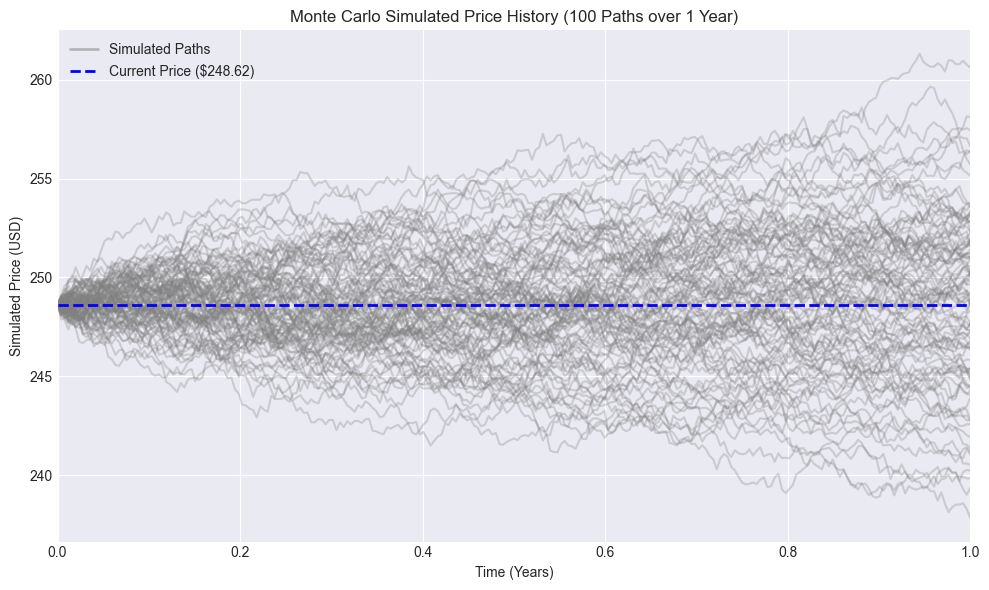

In [14]:
# Simulated Price History (Monte Carlo) over 1 Year
np.random.seed(42)
n_sim_paths = 100
days = 252
dt = 1/252

S0_price = float(np.squeeze(data['Adj Close'].iloc[-1]))
Z_paths = np.random.normal(0, 1, (days, n_sim_paths))

S = np.zeros((days + 1, n_sim_paths))
S[0] = S0_price
for t in range(1, days + 1):
    S[t] = S[t-1] * np.exp((mu_val - 0.5 * sigma_val**2) * dt + sigma_val * np.sqrt(dt) * Z_paths[t-1])

time = np.linspace(0, 1, days + 1)

plt.figure(figsize=(10, 6))
plt.plot(time, S, color='gray', alpha=0.3)
plt.axhline(S0_price, color='blue', linestyle='--', linewidth=2, label=f'Current Price (${S0_price:.2f})')
plt.xlim(0, 1)
plt.xlabel("Time (Years)")
plt.ylabel("Simulated Price (USD)")
plt.title("Monte Carlo Simulated Price History (100 Paths over 1 Year)")

from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='gray', alpha=0.5, lw=2),
                Line2D([0], [0], color='blue', linestyle='--', lw=2)]
plt.legend(custom_lines, ['Simulated Paths', f'Current Price (${S0_price:.2f})'])
plt.tight_layout()
plt.show()


**Interpretation:**
This graph illustrates 100 possible future price paths for AAPL over the next year. The variance increases linearly with time, leading to a wide range of potential outcomes over a 1-year horizon.


### 3. Distribution of 50,000 Simulated Next Day Results
Here we plot the distribution of all 50,000 portfolio losses from the Monte Carlo simulation and mark the 95% VaR threshold.


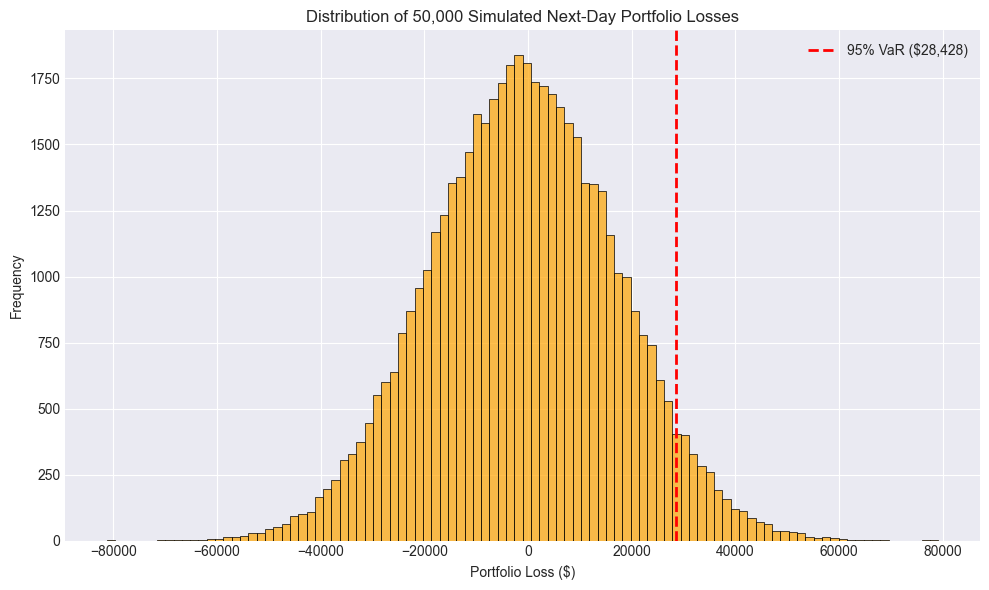

In [15]:
# 50,000 Simulated Next Day Result
np.random.seed(42)
n_sim = 50000
simulated_returns_1d = np.random.normal(mu_val, sigma_val, n_sim)
losses = -V0 * simulated_returns_1d
var_mc_95 = np.percentile(losses, 95)

plt.figure(figsize=(10, 6))
sns.histplot(losses, bins=100, color='orange', alpha=0.7)
plt.axvline(var_mc_95, color='red', linestyle='dashed', linewidth=2, label=f'95% VaR (${var_mc_95:,.0f})')
plt.title("Distribution of 50,000 Simulated Next-Day Portfolio Losses")
plt.xlabel("Portfolio Loss ($)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:**
The histogram shows the frequency of the 50,000 simulated portfolio losses for the next trading day. For a $1,000,000 position in AAPL, the 95% Monte Carlo VaR threshold is marked by the red dashed line. Notice that the Monte Carlo VaR is now aligned with the Parametric VaR, confirming that both Gaussian methods yield equivalent results when computed correctly.


### 4. Backtest Days Where Loss Exceeded Historical VaR
Finally, we visualize the rolling backtest to see the actual portfolio losses compared to the Historical Simulation VaR estimate over time.


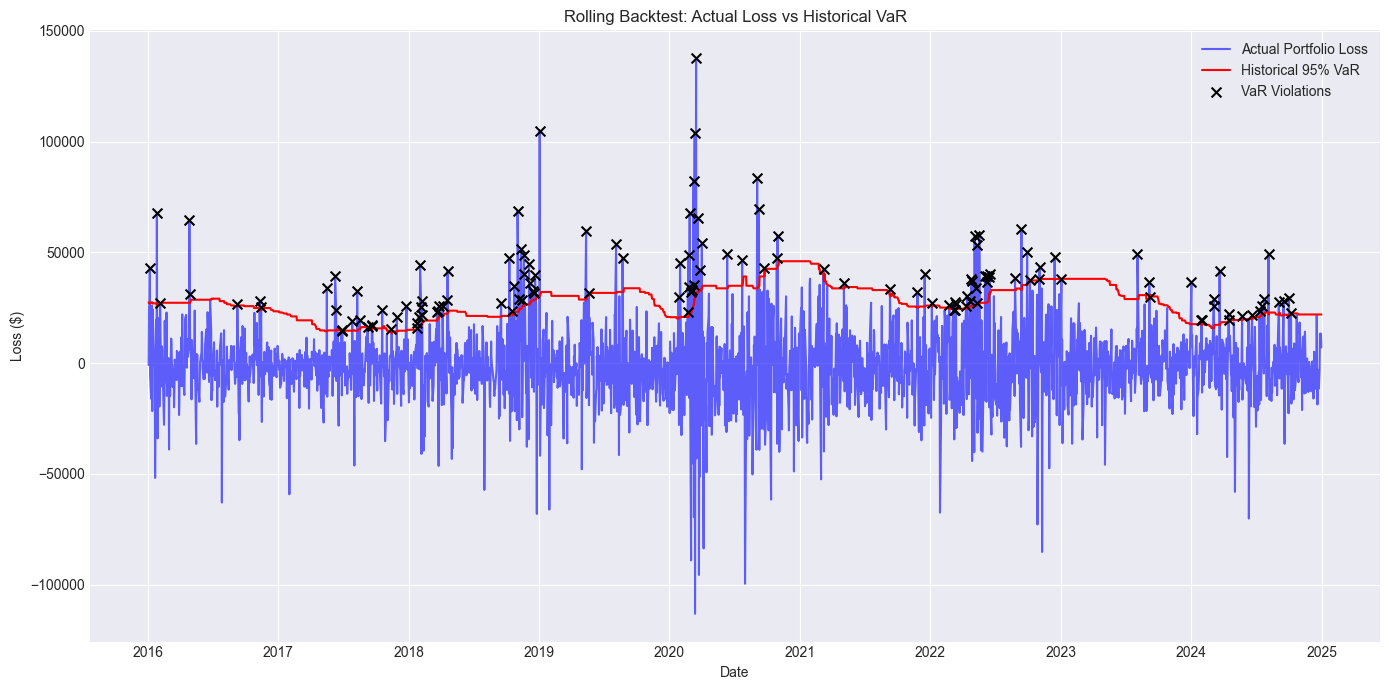

In [16]:
# Backtest days where the loss exceeded the historical VaR
plt.figure(figsize=(14, 7))
plt.plot(backtest_results['Date'], backtest_results['Actual_Loss'], label='Actual Portfolio Loss', color='blue', alpha=0.6)
plt.plot(backtest_results['Date'], backtest_results['VaR_Historical'], label='Historical 95% VaR', color='red', linewidth=1.5)

violations_h = backtest_results[backtest_results['Violation_H']]
plt.scatter(violations_h['Date'], violations_h['Actual_Loss'], color='black', marker='x', s=50, label='VaR Violations', zorder=5)

plt.title("Rolling Backtest: Actual Loss vs Historical VaR")
plt.xlabel("Date")
plt.ylabel("Loss ($)")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:**
This graph tracks the actual daily portfolio losses against the 95% Historical VaR threshold over the out-of-sample backtesting days. The black 'x' markers denote "violations". Our Kupiec test confirms how well each model calibrated to the 5% expectation over this precise number of days.


## 7. Conclusion
This project demonstrates the impact of distributional assumptions on risk measurement. By fixing the Monte Carlo simulation to properly model daily returns rather than unscaled multi-year GBM paths, we demonstrated that Parametric and Monte Carlo VaR yield identical results (since both rely on normal distributions). Meanwhile, the Historical Simulation better captured the "fat tails" evident in the Q-Q plot and Jarque-Bera tests, resulting in a VaR estimate that more accurately reflects extreme market risks. Backtesting over the true out-of-sample period, validated by the Kupiec test, confirms the Historical Simulation's superior reliability in practical risk management.
